In [82]:
### Exploratory data analysis, geothermal reservoir temperature prediction using machine learning techniques.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

data = pd.read_csv('geochemical_data.csv')

In [98]:
### Change commas for dots in original csv file

import csv

input_file = 'geochemical_data.csv'
output_file = 'geochemical_data_mod.csv'

with open(input_file, 'r', newline='', encoding='utf-8') as infile, open(output_file, 'w', newline='', encoding='utf-8') as outfile:
    reader = csv.reader(infile, delimiter=',')
    writer = csv.writer(outfile, delimiter=',')

    for row in reader:
        new_row = [col.replace(',', '.') if col.replace(',','').replace('.','').isdigit() else col for col in row]
        writer.writerow(new_row)

print(f'Processed CSV file as {output_file} to replace commas for dots.')

Processed CSV file as geochemical_data_mod.csv to replace commas for dots.


In [111]:
### Exploratory Data Analysis ###

df = pd.read_csv('geochemical_data_mod.csv')

# Principal information abot the dataset

print('🔹First 5 rows:\n', df.head())
print('\n🔹Last 5 rows:\n', df.tail())
print('\n🔹Dataset Shape:\n', df.shape)
print('\n🔹Column Info: ')
print('\n', df.info())

print('\n🔹Column names:\n', df.columns.tolist())
print('\n🔹Data types:\n', df.dtypes)
print('\n🔹Missing values:\n', df.isnull().sum())
print('\n🔹Duplicates Count:', df.duplicated().sum())

print('\n🔹Summary Statistics:\n', df.describe(include='all').T)


🔹First 5 rows:
                   name manifestation_type geothermal_system       id  t_out  \
0  Rincón de las papas     Thermal spring            Domuyo  RP1(jp)   46.0   
1  Rincón de las papas     Thermal spring            Domuyo  RP2(jp)   40.2   
2  Rincón de las papas     Thermal spring            Domuyo   RP(88)   39.5   
3            El Humazo           Fumarole            Domuyo  EH1(jp)   97.5   
4            El Humazo           Fumarole            Domuyo  EH1(88)   93.5   

    pH  ac_carbonate  chloride  sulfate  calcium  magnesium  sodium  \
0  6.9         740.0     970.0    115.0    102.0       17.2   715.0   
1  7.0         780.0    2900.0     76.0    209.0       50.7  1570.0   
2  6.6        1098.0    2400.0     89.0     78.0       50.0  1495.0   
3  7.2         100.0    2000.0    230.0     34.6        0.2  1330.0   
4  8.2          98.0    1750.0    259.0     33.0        0.4  1185.0   

   potassium  lithium  silica  δ18O-H2O  δD-H2O  T_reservoir  
0       72.0      4


Missing Data:
              Missing Values  Percentage
ac_carbonate               5    2.840909
magnesium                 26   14.772727
lithium                   10    5.681818
silica                     8    4.545455
δ18O-H2O                  45   25.568182
δD-H2O                    39   22.159091


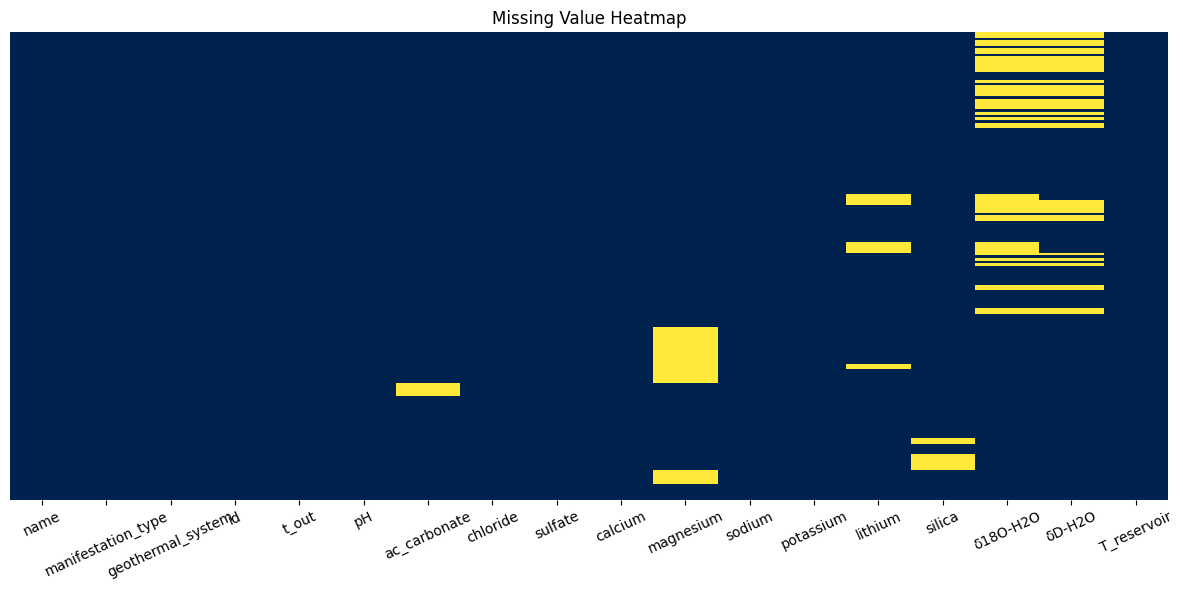

In [112]:
# Handling missing values

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1)
missing_data.columns = ['Missing Values', 'Percentage']
print("\nMissing Data:")
print(missing_data[missing_data['Missing Values'] > 0])

# Visualize missing values
plt.figure(figsize=(12, 6))
plt.title('Missing Value Heatmap')
sns.heatmap(df.isnull(), cbar=False, cmap='cividis', yticklabels=False)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()
plt.close()


In [117]:
# Replace missing values with the median of each column.

df_final = df.apply(lambda x: x.fillna(x.median()) if x.dtype != 'O' else x)

# Return to original negative values for δ18O-H2O and δD-H2O columns
df_final['δ18O-H2O'] = -df_final['δ18O-H2O']
df_final['δD-H2O'] = -df_final['δD-H2O']

print('\n🔹Missing values:\n', df_final.isnull().sum())


🔹Missing values:
 name                  0
manifestation_type    0
geothermal_system     0
id                    0
t_out                 0
pH                    0
ac_carbonate          0
chloride              0
sulfate               0
calcium               0
magnesium             0
sodium                0
potassium             0
lithium               0
silica                0
δ18O-H2O              0
δD-H2O                0
T_reservoir           0
dtype: int64


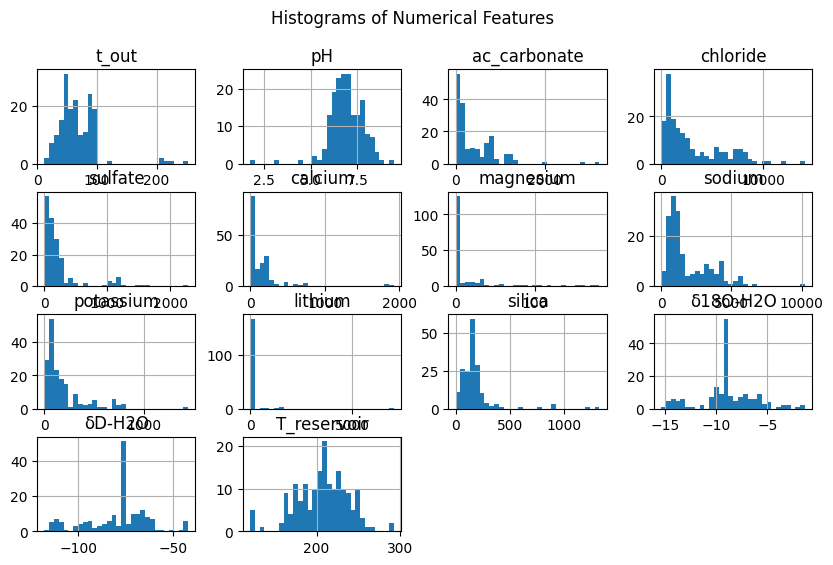

In [121]:
# Distribution plots for numerical columns
numeric_cols = df_final.select_dtypes(include=["number"]).columns  # Select only numeric columns
if not numeric_cols.empty:
    df_final[numeric_cols].hist(figsize=(10, 6), bins=30)
    plt.suptitle("Histograms of Numerical Features")
    plt.show()

In [122]:
# Visualize missing values
plt.figure(figsize=(12, 6))
plt.title('Missing Value Heatmap')
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.tight_layout()
plt.savefig('missing_values.png')
plt.close()

# 5. Explore data distributions
# For numerical columns
numerical_columns = df_final.select_dtypes(include=['int64', 'float64']).columns

# Create histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns[:min(9, len(numerical_columns))]):
    plt.subplot(3, 3, i+1)
    sns.histplot(df_final[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.savefig('numerical_distributions.png')
plt.close()

# For categorical columns
categorical_columns = df_final.select_dtypes(include=['object', 'category']).columns

# Create count plots for categorical features
if len(categorical_columns) > 0:
    plt.figure(figsize=(15, 10))
    for i, column in enumerate(categorical_columns[:min(9, len(categorical_columns))]):
        plt.subplot(3, 3, i+1)
        top_categories = df_final[column].value_counts().nlargest(10).index
        sns.countplot(x=column, data=df_final[df_final[column].isin(top_categories)])
        plt.title(f'Count plot of {column}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('categorical_distributions.png')
    plt.close()

# Box plots for numerical columns to check outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns[:min(9, len(numerical_columns))]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df_final[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.savefig('outliers_boxplot.png')
plt.close()

# 6. Analyze relationships
# Correlation matrix for numerical features
if len(numerical_columns) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df_final[numerical_columns].corr()
    mask = np.triu(correlation_matrix)
    sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='coolwarm', 
                linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png')
    plt.close()

    # Scatter plot for the top correlated features
    corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1]  # Remove self-correlations
    top_pairs = corr_pairs.nlargest(min(3, len(corr_pairs)))
    
    for i, (pair, corr) in enumerate(top_pairs.items()):
        col1, col2 = pair
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=col1, y=col2, data=df)
        plt.title(f'Scatter Plot: {col1} vs {col2} (corr={corr:.2f})')
        plt.tight_layout()
        plt.savefig(f'scatter_{col1}_{col2}.png')
        plt.close()

# If there are both numerical and categorical columns, analyze relationships
if len(numerical_columns) > 0 and len(categorical_columns) > 0:
    # Choose a couple of key numerical variables and categorical variables
    for num_col in numerical_columns[:min(3, len(numerical_columns))]:
        for cat_col in categorical_columns[:min(2, len(categorical_columns))]:
            plt.figure(figsize=(10, 6))
            top_categories = df[cat_col].value_counts().nlargest(5).index
            sns.boxplot(x=cat_col, y=num_col, data=df[df[cat_col].isin(top_categories)])
            plt.title(f'{cat_col} vs {num_col}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(f'boxplot_{cat_col}_{num_col}.png')
            plt.close()

print("\nExploratory Data Analysis completed! Visualizations saved as PNG files.")


Exploratory Data Analysis completed! Visualizations saved as PNG files.
